# 问题四：基于 NTU 超标幅度与持续时长的水质风险评价体系

本 notebook 对应 A 题第四问。

第四问要求以出厂水浊度 `NTU` 为核心指标，结合**超标幅度**与**异常持续时长**，将 2026 年近 3 个月水质划分为：

```text
安全、低风险、中风险、高风险
```

并给出：

```text
1. 各等级天数占比；
2. 2026 年 3 月份每日具体分类结果；
3. Excel 表格和可视化图像。
```

国标硬约束：

```text
生活饮用水浊度限值 ≤ 1 NTU
```

本题不是预测模型题，而是**风险评价体系构建题**。因此不使用 RF、XGBoost、GRU，只使用原始 `NTU` 做 rule-based classification。

注意：

```text
第四题必须使用未标准化、未 clipping 的原始 NTU。
F/RIDE 是否填 0 不影响第四题，因为风险分类只使用 NTU。
```


## 1. 导入依赖库

本题主要使用 `pandas` 做数据统计，使用 `matplotlib` 画图。  
所有输出文件统一保存在：

```text
outputs/problem4/
```


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("依赖库导入完成。")


依赖库导入完成。


## 2. 参数设置

风险评价核心阈值：

```text
NTU_THRESHOLD = 1.0
```

风险等级规则：

| 风险等级 | 判定逻辑 |
|---|---|
| 安全 | 全天无超标，即 `max_NTU ≤ 1` |
| 低风险 | 轻微短时超标：`max_excess ≤ 0.2` 且 `exceed_duration_hours ≤ 2` |
| 高风险 | 大幅或持续超标：`max_excess > 0.5` 或 `exceed_duration_hours ≥ 6` 或 `max_consecutive_exceed_hours ≥ 4` |
| 中风险 | 有超标，但不属于低风险或高风险 |

其中：

```text
excess = max(NTU - 1, 0)
```


In [2]:
TARGET_COL = "NTU"

# 国标硬约束
NTU_THRESHOLD = 1.0

# 数据每 2 小时一条记录
RECORD_INTERVAL_HOURS = 2.0

# 第四题“2026 年近 3 个月”
RISK_START_DATE = "2026-01-01"
RISK_END_DATE = "2026-03-31"

# 单独输出 3 月份结果
MARCH_START_DATE = "2026-03-01"
MARCH_END_DATE = "2026-03-31"

# 风险规则参数
LOW_RISK_MAX_EXCESS = 0.2
LOW_RISK_MAX_DURATION_HOURS = 2.0

HIGH_RISK_MAX_EXCESS = 0.5
HIGH_RISK_MIN_DURATION_HOURS = 6.0
HIGH_RISK_MIN_CONSECUTIVE_HOURS = 4.0

OUTPUT_DIR_NAME = "problem4"

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

第四题应从原始合并数据 `merged.xlsx` 出发。  
不要使用 selected-lag、standardized 或 clipping 之后的数据文件。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    """
    自动定位 merged.xlsx。
    兼容从项目根目录运行和从 codes/ 文件夹运行两种情况。
    """
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []
    for path in candidates:
        path = path.resolve()
        if path not in seen:
            seen.add(path)
            unique_candidates.append(path)

    for path in unique_candidates:
        if path.exists():
            return path

    # 最后尝试递归搜索
    for path in cwd.rglob(filename):
        return path.resolve()

    searched = "\n".join(str(path) for path in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4


## 4. 读取数据并检查 NTU

这里读取 `merged.xlsx`，并检查 `NTU` 是否存在。  
第四题必须使用真实 NTU 值，不应使用标准化或 clipping 后的 NTU。


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标列 {TARGET_COL}。请检查 merged.xlsx。")

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

print("\nNTU 描述统计：")
display(df[TARGET_COL].describe())

print("\nNTU 超标检查：")
print("NTU > 1 count:", int((df[TARGET_COL] > 1).sum()))
print("NTU > 2 count:", int((df[TARGET_COL] > 2).sum()))
print("NTU max:", df[TARGET_COL].max(skipna=True))

display(df.head())


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']

NTU 描述统计：


count    5124.000000
mean        0.445794
std         0.616311
min         0.080000
25%         0.200000
50%         0.310000
75%         0.510000
max        11.900000
Name: NTU, dtype: float64


NTU 超标检查：
NTU > 1 count: 179
NTU > 2 count: 96
NTU max: 11.9


,DATE,TIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,C/W WELL LEVEL,PH,NTU,CLR,CL2,F/RIDE,ALUM,T/W PUMP DUTY,T/W FLOW
0,2025-01-01,07:00:00,6.22,1.0,45.3,150,850.0,7.0,0.04,3.82,7.2,0.12,5.0,1.5,0.0,0.04,2.0,42.6
1,2025-01-01,09:00:00,6.34,1.0,45.2,120,830.0,7.0,0.05,3.81,7.2,0.12,5.0,1.5,0.0,0.04,2.0,42.6
2,2025-01-01,11:00:00,6.17,1.0,44.9,82,780.0,7.0,0.05,3.81,7.2,0.12,5.0,1.6,0.0,0.04,2.0,42.7
3,2025-01-01,13:00:00,5.99,1.0,44.9,62,720.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,0.0,0.04,2.0,42.3
4,2025-01-01,15:00:00,5.83,1.0,44.5,56,641.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,0.0,0.04,2.0,42.5


## 5. 构造时间列 `DATETIME` 和运行日 `OP_DATE`

沿用前面问题的运行日定义：

```text
07:00, 09:00, ..., 23:00, 次日 01:00, 03:00, 05:00
```

归为同一个运行日。


In [5]:
def construct_datetime(data):
    """
    从 DATETIME 或 DATE + TIME 构造标准时间列。
    """
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(date_text + " " + time_text, errors="coerce")
    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

# 构造 OP_DATE
df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
print("DATETIME 缺失数：", df["DATETIME"].isna().sum())

display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(15))
display(df[["DATETIME", "OP_DATE", TARGET_COL]].tail(15))


时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00
DATETIME 缺失数： 0


,DATETIME,OP_DATE,NTU
0,2025-01-01 07:00:00,2025-01-01,0.12
1,2025-01-01 09:00:00,2025-01-01,0.12
2,2025-01-01 11:00:00,2025-01-01,0.12
3,2025-01-01 13:00:00,2025-01-01,0.11
4,2025-01-01 15:00:00,2025-01-01,0.11
5,2025-01-01 17:00:00,2025-01-01,0.11
6,2025-01-01 19:00:00,2025-01-01,0.11
7,2025-01-01 21:00:00,2025-01-01,0.11
8,2025-01-01 23:00:00,2025-01-01,0.12
9,2025-01-02 01:00:00,2025-01-01,0.12


,DATETIME,OP_DATE,NTU
5445,2026-03-31 01:00:00,2026-03-30,0.25
5446,2026-03-31 03:00:00,2026-03-30,0.25
5447,2026-03-31 05:00:00,2026-03-30,0.25
5448,2026-03-31 07:00:00,2026-03-31,0.25
5449,2026-03-31 09:00:00,2026-03-31,0.25
5450,2026-03-31 11:00:00,2026-03-31,0.24
5451,2026-03-31 13:00:00,2026-03-31,0.24
5452,2026-03-31 15:00:00,2026-03-31,0.27
5453,2026-03-31 17:00:00,2026-03-31,0.27
5454,2026-03-31 19:00:00,2026-03-31,0.26


## 6. 筛选 2026 年近 3 个月数据

题目要求评价 2026 年近 3 个月。  
本 notebook 默认使用：

```text
2026-01-01 至 2026-03-31
```

如果数据中没有完整范围，会在输出中显示实际筛选到的数据范围。


In [6]:
df["OP_DATE_DT"] = pd.to_datetime(df["OP_DATE"])

risk_start = pd.to_datetime(RISK_START_DATE)
risk_end = pd.to_datetime(RISK_END_DATE)

risk_df = df[
    (df["OP_DATE_DT"] >= risk_start) &
    (df["OP_DATE_DT"] <= risk_end)
].copy()

risk_df = risk_df.dropna(subset=[TARGET_COL]).sort_values("DATETIME").reset_index(drop=True)

if len(risk_df) == 0:
    raise ValueError(f"在 {RISK_START_DATE} 至 {RISK_END_DATE} 范围内没有找到可用 NTU 数据。")

print("风险评价数据规模：", risk_df.shape)
print("实际 OP_DATE 范围：", risk_df["OP_DATE_DT"].min(), "至", risk_df["OP_DATE_DT"].max())
print("实际 DATETIME 范围：", risk_df["DATETIME"].min(), "至", risk_df["DATETIME"].max())

display(risk_df[["DATETIME", "OP_DATE", TARGET_COL]].head())
display(risk_df[["DATETIME", "OP_DATE", TARGET_COL]].tail())


风险评价数据规模： (744, 21)
实际 OP_DATE 范围： 2026-01-01 00:00:00 至 2026-03-31 00:00:00
实际 DATETIME 范围： 2026-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,NTU
0,2026-01-01 07:00:00,2026-01-01,0.19
1,2026-01-01 09:00:00,2026-01-01,0.19
2,2026-01-01 11:00:00,2026-01-01,0.19
3,2026-01-01 13:00:00,2026-01-01,0.19
4,2026-01-01 15:00:00,2026-01-01,0.19


,DATETIME,OP_DATE,NTU
739,2026-03-31 21:00:00,2026-03-31,0.27
740,2026-03-31 23:00:00,2026-03-31,0.26
741,2026-04-01 01:00:00,2026-03-31,0.25
742,2026-04-01 03:00:00,2026-03-31,0.25
743,2026-04-01 05:00:00,2026-03-31,0.23


## 7. 逐时间点超标状态计算

对每个时间点计算：

```text
is_exceed = NTU > 1
excess = max(NTU - 1, 0)
```

逐点结果保存为：

```text
outputs/problem4/problem4_point_level_status.xlsx
```


In [7]:
point_df = risk_df[["DATETIME", "OP_DATE", "OP_DATE_DT", TARGET_COL]].copy()

point_df["threshold_NTU"] = NTU_THRESHOLD
point_df["is_exceed"] = point_df[TARGET_COL] > NTU_THRESHOLD
point_df["excess"] = (point_df[TARGET_COL] - NTU_THRESHOLD).clip(lower=0)

point_df["status"] = np.where(point_df["is_exceed"], "EXCEED", "NORMAL")
point_df["status_cn"] = np.where(point_df["is_exceed"], "超标", "正常")

point_status_path = OUTPUT_DIR / "problem4_point_level_status.xlsx"
point_df.to_excel(point_status_path, index=False)

print("逐时间点超标状态表已保存：", point_status_path)
display(point_df.head(20))


逐时间点超标状态表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_point_level_status.xlsx


,DATETIME,OP_DATE,OP_DATE_DT,NTU,threshold_NTU,is_exceed,excess,status,status_cn
0,2026-01-01 07:00:00,2026-01-01,2026-01-01,0.19,1.0,False,0.0,NORMAL,正常
1,2026-01-01 09:00:00,2026-01-01,2026-01-01,0.19,1.0,False,0.0,NORMAL,正常
2,2026-01-01 11:00:00,2026-01-01,2026-01-01,0.19,1.0,False,0.0,NORMAL,正常
3,2026-01-01 13:00:00,2026-01-01,2026-01-01,0.19,1.0,False,0.0,NORMAL,正常
4,2026-01-01 15:00:00,2026-01-01,2026-01-01,0.19,1.0,False,0.0,NORMAL,正常
5,2026-01-01 17:00:00,2026-01-01,2026-01-01,0.17,1.0,False,0.0,NORMAL,正常
6,2026-01-01 19:00:00,2026-01-01,2026-01-01,0.17,1.0,False,0.0,NORMAL,正常
7,2026-01-01 21:00:00,2026-01-01,2026-01-01,0.17,1.0,False,0.0,NORMAL,正常
8,2026-01-01 23:00:00,2026-01-01,2026-01-01,0.17,1.0,False,0.0,NORMAL,正常
9,2026-01-02 01:00:00,2026-01-01,2026-01-01,0.18,1.0,False,0.0,NORMAL,正常


## 8. 计算每日最长连续超标时长

连续超标点数乘以记录间隔 2 小时，得到最长连续超标时长。


In [8]:
def max_consecutive_true(bool_series):
    """
    计算布尔序列中最长连续 True 的长度。
    """
    max_run = 0
    current_run = 0

    for val in bool_series:
        if bool(val):
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0

    return max_run


consecutive_records = []

for op_date, group in point_df.groupby("OP_DATE"):
    group = group.sort_values("DATETIME")
    max_consecutive_count = max_consecutive_true(group["is_exceed"].values)
    max_consecutive_hours = max_consecutive_count * RECORD_INTERVAL_HOURS

    consecutive_records.append({
        "OP_DATE": op_date,
        "max_consecutive_exceed_count": max_consecutive_count,
        "max_consecutive_exceed_hours": max_consecutive_hours,
    })

consecutive_df = pd.DataFrame(consecutive_records)
display(consecutive_df.head())


,OP_DATE,max_consecutive_exceed_count,max_consecutive_exceed_hours
0,2026-01-01,0,0.0
1,2026-01-02,0,0.0
2,2026-01-03,0,0.0
3,2026-01-04,0,0.0
4,2026-01-05,0,0.0


## 9. 按运行日汇总风险指标

对每个 `OP_DATE` 计算：

```text
n_records
mean_NTU
max_NTU
exceed_count
exceed_ratio
exceed_duration_hours
max_excess
excess_area
max_consecutive_exceed_hours
```


In [9]:
daily_base = (
    point_df
    .groupby("OP_DATE", as_index=False)
    .agg(
        n_records=(TARGET_COL, "count"),
        mean_NTU=(TARGET_COL, "mean"),
        max_NTU=(TARGET_COL, "max"),
        min_NTU=(TARGET_COL, "min"),
        std_NTU=(TARGET_COL, "std"),
        exceed_count=("is_exceed", "sum"),
        max_excess=("excess", "max"),
        mean_excess=("excess", "mean"),
        total_excess=("excess", "sum"),
    )
)

daily_base["exceed_ratio"] = daily_base["exceed_count"] / daily_base["n_records"]
daily_base["exceed_duration_hours"] = daily_base["exceed_count"] * RECORD_INTERVAL_HOURS
daily_base["excess_area"] = daily_base["total_excess"] * RECORD_INTERVAL_HOURS

daily_risk_indicators = daily_base.merge(consecutive_df, on="OP_DATE", how="left")
daily_risk_indicators["OP_DATE_DT"] = pd.to_datetime(daily_risk_indicators["OP_DATE"])
daily_risk_indicators = daily_risk_indicators.sort_values("OP_DATE_DT").reset_index(drop=True)

indicator_cols = [
    "OP_DATE",
    "OP_DATE_DT",
    "n_records",
    "mean_NTU",
    "max_NTU",
    "min_NTU",
    "std_NTU",
    "exceed_count",
    "exceed_ratio",
    "exceed_duration_hours",
    "max_excess",
    "mean_excess",
    "total_excess",
    "excess_area",
    "max_consecutive_exceed_count",
    "max_consecutive_exceed_hours",
]

daily_risk_indicators = daily_risk_indicators[indicator_cols]

daily_indicators_path = OUTPUT_DIR / "problem4_daily_risk_indicators.xlsx"
daily_risk_indicators.to_excel(daily_indicators_path, index=False)

print("每日风险指标表已保存：", daily_indicators_path)
display(daily_risk_indicators.head())


每日风险指标表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_daily_risk_indicators.xlsx


,OP_DATE,OP_DATE_DT,n_records,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,exceed_ratio,exceed_duration_hours,max_excess,mean_excess,total_excess,excess_area,max_consecutive_exceed_count,max_consecutive_exceed_hours
0,2026-01-01,2026-01-01,12,0.180833,0.19,0.17,0.009003,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
1,2026-01-02,2026-01-02,12,0.190000,0.22,0.17,0.015374,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
2,2026-01-03,2026-01-03,12,0.170000,0.18,0.16,0.006030,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
3,2026-01-04,2026-01-04,12,0.168333,0.17,0.16,0.003892,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
4,2026-01-05,2026-01-05,12,0.170833,0.18,0.17,0.002887,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0


## 10. 建立四等级风险分类规则

风险等级：

```text
SAFE        安全
LOW_RISK    低风险
MEDIUM_RISK 中风险
HIGH_RISK   高风险
```


In [10]:
def classify_risk(row):
    """
    基于超标幅度、累计持续时长、连续超标时长划分风险等级。
    """
    max_ntu = row["max_NTU"]
    max_excess = row["max_excess"]
    duration = row["exceed_duration_hours"]
    consecutive = row["max_consecutive_exceed_hours"]

    if pd.isna(max_ntu):
        return "UNKNOWN", "未知", "NTU 数据缺失"

    if max_ntu <= NTU_THRESHOLD:
        return "SAFE", "安全", "全天未超标"

    if (
        max_excess <= LOW_RISK_MAX_EXCESS and
        duration <= LOW_RISK_MAX_DURATION_HOURS
    ):
        return "LOW_RISK", "低风险", "轻微短时超标"

    if (
        max_excess > HIGH_RISK_MAX_EXCESS or
        duration >= HIGH_RISK_MIN_DURATION_HOURS or
        consecutive >= HIGH_RISK_MIN_CONSECUTIVE_HOURS
    ):
        reasons = []
        if max_excess > HIGH_RISK_MAX_EXCESS:
            reasons.append("最大超标幅度较大")
        if duration >= HIGH_RISK_MIN_DURATION_HOURS:
            reasons.append("累计超标持续时间较长")
        if consecutive >= HIGH_RISK_MIN_CONSECUTIVE_HOURS:
            reasons.append("连续超标时间较长")
        return "HIGH_RISK", "高风险", "；".join(reasons)

    return "MEDIUM_RISK", "中风险", "存在一定超标但未达到高风险"


classification_records = []

for _, row in daily_risk_indicators.iterrows():
    risk_level, risk_level_cn, main_reason = classify_risk(row)
    record = row.to_dict()
    record["risk_level"] = risk_level
    record["risk_level_cn"] = risk_level_cn
    record["main_reason"] = main_reason
    classification_records.append(record)

daily_classification = pd.DataFrame(classification_records)

risk_order_map = {
    "SAFE": 0,
    "LOW_RISK": 1,
    "MEDIUM_RISK": 2,
    "HIGH_RISK": 3,
    "UNKNOWN": 99,
}

daily_classification["risk_order"] = daily_classification["risk_level"].map(risk_order_map)

daily_classification_path = OUTPUT_DIR / "problem4_daily_risk_classification.xlsx"
daily_classification.to_excel(daily_classification_path, index=False)

print("每日风险分类表已保存：", daily_classification_path)
display(daily_classification.head(20))


每日风险分类表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_daily_risk_classification.xlsx


,OP_DATE,OP_DATE_DT,n_records,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,exceed_ratio,exceed_duration_hours,max_excess,mean_excess,total_excess,excess_area,max_consecutive_exceed_count,max_consecutive_exceed_hours,risk_level,risk_level_cn,main_reason,risk_order
0,2026-01-01,2026-01-01,12,0.180833,0.19,0.17,0.009003,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
1,2026-01-02,2026-01-02,12,0.190000,0.22,0.17,0.015374,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
2,2026-01-03,2026-01-03,12,0.170000,0.18,0.16,0.006030,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
3,2026-01-04,2026-01-04,12,0.168333,0.17,0.16,0.003892,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
4,2026-01-05,2026-01-05,12,0.170833,0.18,0.17,0.002887,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
5,2026-01-06,2026-01-06,12,0.171667,0.18,0.16,0.008348,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
6,2026-01-07,2026-01-07,12,0.178333,0.20,0.17,0.010299,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
7,2026-01-08,2026-01-08,12,0.209167,0.24,0.17,0.023143,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
8,2026-01-09,2026-01-09,12,0.355000,0.74,0.22,0.176815,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
9,2026-01-10,2026-01-10,12,0.888333,2.15,0.25,0.699114,4,0.333333,8.0,1.15,0.243333,2.92,5.84,4,8.0,HIGH_RISK,高风险,最大超标幅度较大；累计超标持续时间较长；连续超标时间较长,3


## 11. 统计四类风险等级天数占比

输出：

```text
outputs/problem4/problem4_risk_level_proportion.xlsx
```


In [11]:
total_days = len(daily_classification)

risk_level_order = ["SAFE", "LOW_RISK", "MEDIUM_RISK", "HIGH_RISK", "UNKNOWN"]
risk_level_cn_map = {
    "SAFE": "安全",
    "LOW_RISK": "低风险",
    "MEDIUM_RISK": "中风险",
    "HIGH_RISK": "高风险",
    "UNKNOWN": "未知",
}

risk_proportion = (
    daily_classification
    .groupby("risk_level", as_index=False)
    .agg(days=("OP_DATE", "count"))
)

risk_proportion = pd.DataFrame({"risk_level": risk_level_order}).merge(
    risk_proportion,
    on="risk_level",
    how="left"
)

risk_proportion["days"] = risk_proportion["days"].fillna(0).astype(int)
risk_proportion["risk_level_cn"] = risk_proportion["risk_level"].map(risk_level_cn_map)
risk_proportion["proportion"] = risk_proportion["days"] / total_days
risk_proportion["proportion_percent"] = risk_proportion["proportion"] * 100

risk_proportion = risk_proportion[
    ["risk_level", "risk_level_cn", "days", "proportion", "proportion_percent"]
]

risk_proportion_path = OUTPUT_DIR / "problem4_risk_level_proportion.xlsx"
risk_proportion.to_excel(risk_proportion_path, index=False)

print("风险等级天数占比表已保存：", risk_proportion_path)
display(risk_proportion)


风险等级天数占比表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_risk_level_proportion.xlsx


,risk_level,risk_level_cn,days,proportion,proportion_percent
0,SAFE,安全,58,0.935484,93.548387
1,LOW_RISK,低风险,1,0.016129,1.612903
2,MEDIUM_RISK,中风险,0,0.000000,0.000000
3,HIGH_RISK,高风险,3,0.048387,4.838710
4,UNKNOWN,未知,0,0.000000,0.000000


## 12. 输出 2026 年 3 月每日风险分类结果

题目明确要求给出 3 月份具体分类结果。

输出：

```text
outputs/problem4/problem4_march_daily_classification.xlsx
```


In [12]:
march_start = pd.to_datetime(MARCH_START_DATE)
march_end = pd.to_datetime(MARCH_END_DATE)

march_classification = daily_classification[
    (daily_classification["OP_DATE_DT"] >= march_start) &
    (daily_classification["OP_DATE_DT"] <= march_end)
].copy()

march_classification = march_classification.sort_values("OP_DATE_DT").reset_index(drop=True)

march_cols = [
    "OP_DATE",
    "n_records",
    "mean_NTU",
    "max_NTU",
    "min_NTU",
    "std_NTU",
    "exceed_count",
    "exceed_ratio",
    "exceed_duration_hours",
    "max_excess",
    "excess_area",
    "max_consecutive_exceed_hours",
    "risk_level",
    "risk_level_cn",
    "main_reason",
]

march_classification = march_classification[march_cols]

march_classification_path = OUTPUT_DIR / "problem4_march_daily_classification.xlsx"
march_classification.to_excel(march_classification_path, index=False)

print("3 月份每日风险分类结果已保存：", march_classification_path)
print("3 月份天数：", len(march_classification))
display(march_classification)


3 月份每日风险分类结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_march_daily_classification.xlsx
3 月份天数： 31


,OP_DATE,n_records,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,exceed_ratio,exceed_duration_hours,max_excess,excess_area,max_consecutive_exceed_hours,risk_level,risk_level_cn,main_reason
0,2026-03-01,12,0.452500,0.48,0.42,0.016583,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
1,2026-03-02,12,0.473333,0.49,0.45,0.015570,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
2,2026-03-03,12,0.493333,0.51,0.47,0.014355,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
3,2026-03-04,12,0.501667,0.52,0.48,0.016967,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
4,2026-03-05,12,0.530833,0.56,0.51,0.017299,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
5,2026-03-06,12,0.540000,0.56,0.52,0.009535,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
6,2026-03-07,12,0.525000,0.54,0.51,0.011677,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
7,2026-03-08,12,0.536667,0.56,0.52,0.014355,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
8,2026-03-09,12,0.544167,0.56,0.53,0.009962,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
9,2026-03-10,12,0.539167,0.55,0.53,0.007930,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标


## 13. 输出汇总工作簿

生成一个总 Excel：

```text
outputs/problem4/problem4_risk_assessment_summary.xlsx
```

包含：

```text
point_level_status
daily_indicators
daily_classification
risk_proportion
march_classification
risk_rules
```


In [13]:
risk_rules = pd.DataFrame([
    {
        "risk_level": "SAFE",
        "risk_level_cn": "安全",
        "rule": "max_NTU ≤ 1",
        "meaning": "全天无超标",
    },
    {
        "risk_level": "LOW_RISK",
        "risk_level_cn": "低风险",
        "rule": "max_NTU > 1 and max_excess ≤ 0.2 and exceed_duration_hours ≤ 2",
        "meaning": "轻微短时超标",
    },
    {
        "risk_level": "MEDIUM_RISK",
        "risk_level_cn": "中风险",
        "rule": "有超标，但未达到高风险，且不属于低风险",
        "meaning": "存在一定超标风险",
    },
    {
        "risk_level": "HIGH_RISK",
        "risk_level_cn": "高风险",
        "rule": "max_excess > 0.5 or exceed_duration_hours ≥ 6 or max_consecutive_exceed_hours ≥ 4",
        "meaning": "大幅度或长时间持续超标",
    },
])

summary_workbook_path = OUTPUT_DIR / "problem4_risk_assessment_summary.xlsx"

with pd.ExcelWriter(summary_workbook_path, engine="openpyxl") as writer:
    point_df.to_excel(writer, sheet_name="point_level_status", index=False)
    daily_risk_indicators.to_excel(writer, sheet_name="daily_indicators", index=False)
    daily_classification.to_excel(writer, sheet_name="daily_classification", index=False)
    risk_proportion.to_excel(writer, sheet_name="risk_proportion", index=False)
    march_classification.to_excel(writer, sheet_name="march_classification", index=False)
    risk_rules.to_excel(writer, sheet_name="risk_rules", index=False)

print("第四题汇总工作簿已保存：", summary_workbook_path)
display(risk_rules)


第四题汇总工作簿已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_risk_assessment_summary.xlsx


,risk_level,risk_level_cn,rule,meaning
0,SAFE,安全,max_NTU ≤ 1,全天无超标
1,LOW_RISK,低风险,max_NTU > 1 and max_excess ≤ 0.2 and exceed_du...,轻微短时超标
2,MEDIUM_RISK,中风险,有超标，但未达到高风险，且不属于低风险,存在一定超标风险
3,HIGH_RISK,高风险,max_excess > 0.5 or exceed_duration_hours ≥ 6 ...,大幅度或长时间持续超标


## 14. 可视化 1：每日最大 NTU 曲线

绘制近 3 个月每日最大 NTU，并画出国标阈值线：

```text
NTU = 1
```


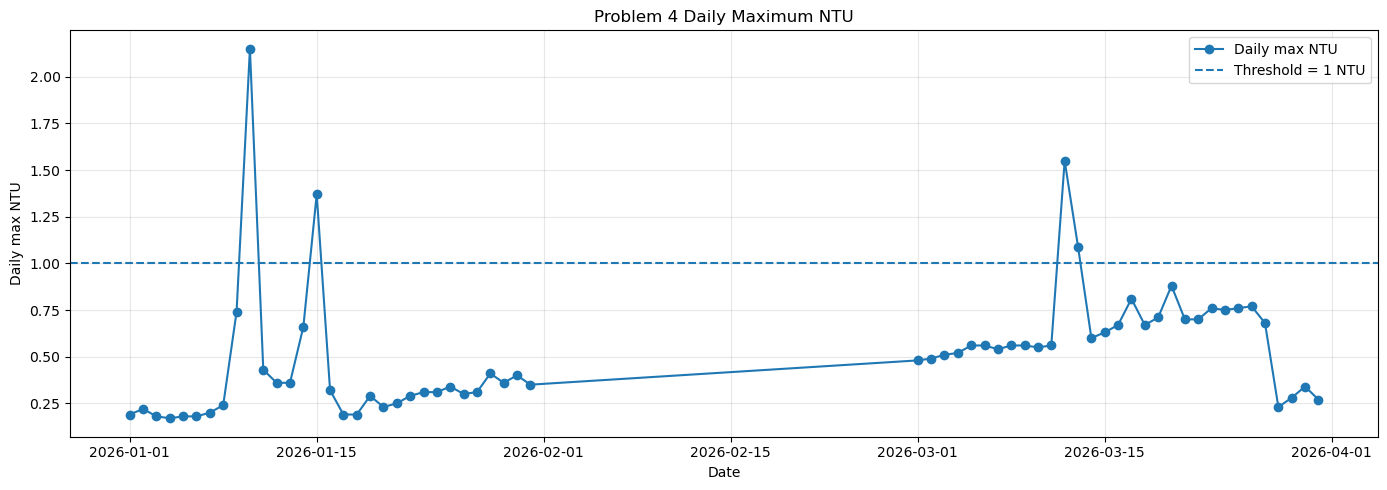

每日最大 NTU 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\figures\problem4_daily_max_ntu.png


In [14]:
plt.figure(figsize=(14, 5))
plt.plot(
    daily_classification["OP_DATE_DT"],
    daily_classification["max_NTU"],
    marker="o",
    linewidth=1.5,
    label="Daily max NTU",
)

plt.axhline(NTU_THRESHOLD, linestyle="--", linewidth=1.5, label="Threshold = 1 NTU")
plt.title("Problem 4 Daily Maximum NTU")
plt.xlabel("Date")
plt.ylabel("Daily max NTU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

daily_max_fig_path = FIG_DIR / "problem4_daily_max_ntu.png"
plt.savefig(daily_max_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("每日最大 NTU 图已保存：", daily_max_fig_path)


## 15. 可视化 2：每日风险等级时间序列

将风险等级映射为数值：

```text
安全 = 0
低风险 = 1
中风险 = 2
高风险 = 3
```


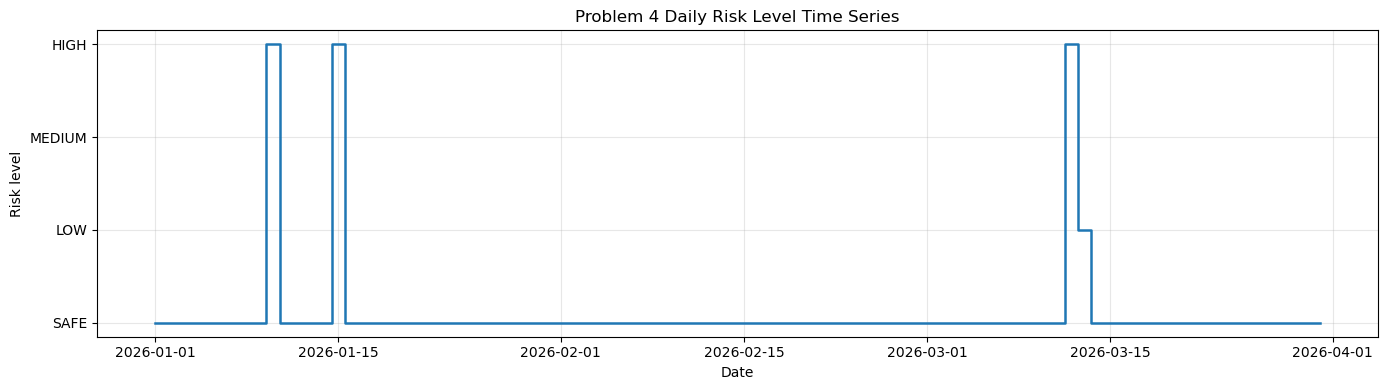

每日风险等级时间序列图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\figures\problem4_daily_risk_level_timeseries.png


In [15]:
plot_df = daily_classification.copy()

plt.figure(figsize=(14, 4))
plt.step(
    plot_df["OP_DATE_DT"],
    plot_df["risk_order"],
    where="mid",
    linewidth=1.8,
)

plt.yticks([0, 1, 2, 3], ["SAFE", "LOW", "MEDIUM", "HIGH"])
plt.title("Problem 4 Daily Risk Level Time Series")
plt.xlabel("Date")
plt.ylabel("Risk level")
plt.grid(alpha=0.3)
plt.tight_layout()

risk_ts_fig_path = FIG_DIR / "problem4_daily_risk_level_timeseries.png"
plt.savefig(risk_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("每日风险等级时间序列图已保存：", risk_ts_fig_path)


## 16. 可视化 3：风险等级天数占比柱状图

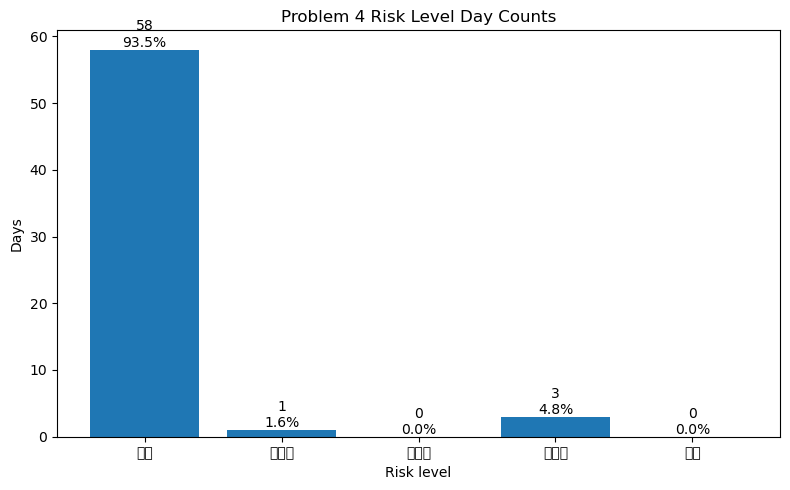

风险等级天数占比图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\figures\problem4_risk_level_proportion.png


In [16]:
plt.figure(figsize=(8, 5))
plt.bar(
    risk_proportion["risk_level_cn"],
    risk_proportion["days"],
)

plt.title("Problem 4 Risk Level Day Counts")
plt.xlabel("Risk level")
plt.ylabel("Days")

for idx, row in risk_proportion.iterrows():
    plt.text(
        idx,
        row["days"],
        f'{row["days"]}\n{row["proportion_percent"]:.1f}%',
        ha="center",
        va="bottom",
    )

plt.tight_layout()

proportion_fig_path = FIG_DIR / "problem4_risk_level_proportion.png"
plt.savefig(proportion_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("风险等级天数占比图已保存：", proportion_fig_path)


## 17. 可视化 4：3 月份每日最大 NTU 与风险等级

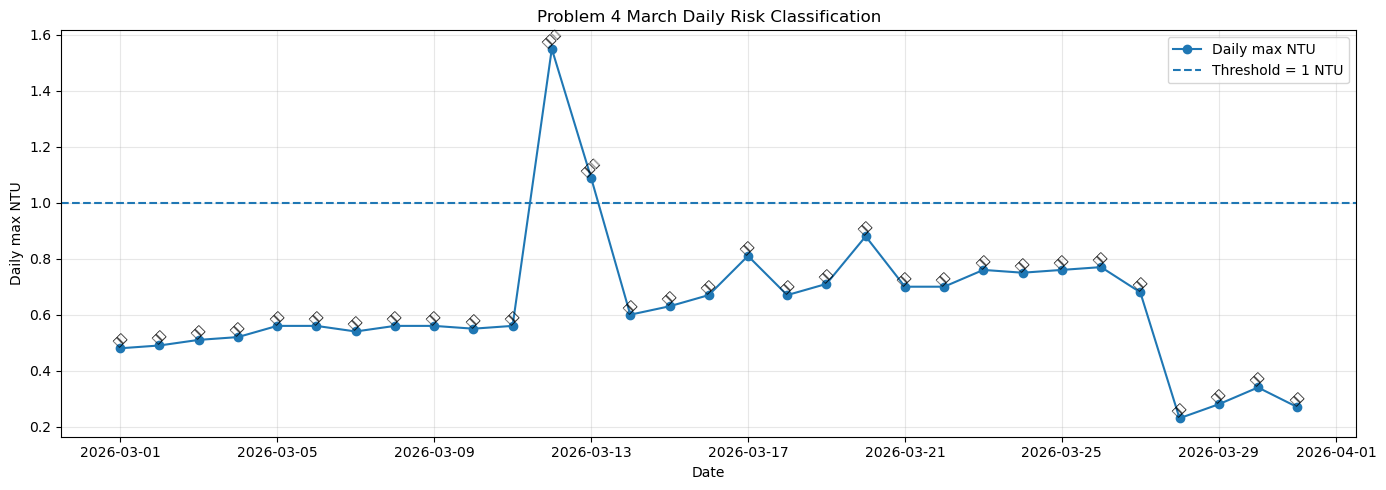

3 月份每日风险分类图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\figures\problem4_march_daily_risk.png


In [17]:
march_plot_df = daily_classification[
    (daily_classification["OP_DATE_DT"] >= march_start) &
    (daily_classification["OP_DATE_DT"] <= march_end)
].copy()

if len(march_plot_df) > 0:
    plt.figure(figsize=(14, 5))
    plt.plot(
        march_plot_df["OP_DATE_DT"],
        march_plot_df["max_NTU"],
        marker="o",
        linewidth=1.5,
        label="Daily max NTU",
    )

    plt.axhline(NTU_THRESHOLD, linestyle="--", linewidth=1.5, label="Threshold = 1 NTU")

    # 标注风险等级
    for _, row in march_plot_df.iterrows():
        plt.text(
            row["OP_DATE_DT"],
            row["max_NTU"],
            row["risk_level_cn"],
            fontsize=8,
            rotation=45,
            ha="center",
            va="bottom",
        )

    plt.title("Problem 4 March Daily Risk Classification")
    plt.xlabel("Date")
    plt.ylabel("Daily max NTU")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    march_fig_path = FIG_DIR / "problem4_march_daily_risk.png"
    plt.savefig(march_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("3 月份每日风险分类图已保存：", march_fig_path)
else:
    print("3 月份数据为空，跳过 3 月份图像绘制。")


## 18. 最终汇总

运行到这里后，第四题的编程部分已经完成。

重点交付文件：

```text
outputs/problem4/problem4_point_level_status.xlsx
outputs/problem4/problem4_daily_risk_indicators.xlsx
outputs/problem4/problem4_daily_risk_classification.xlsx
outputs/problem4/problem4_risk_level_proportion.xlsx
outputs/problem4/problem4_march_daily_classification.xlsx
outputs/problem4/problem4_risk_assessment_summary.xlsx
outputs/problem4/figures/
```


In [18]:
print("=" * 80)
print("第四题水质风险评价体系已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. 逐时间点超标状态：", point_status_path)
print("2. 每日风险指标：", daily_indicators_path)
print("3. 每日风险分类：", daily_classification_path)
print("4. 风险等级天数占比：", risk_proportion_path)
print("5. 3 月份每日分类：", march_classification_path)
print("6. 汇总工作簿：", summary_workbook_path)
print("7. 图片目录：", FIG_DIR)

print("\n风险等级天数占比：")
display(risk_proportion)

print("\n3 月份每日分类结果：")
display(march_classification)

print("\n每日风险分类预览：")
display(daily_classification.head(20))


第四题水质风险评价体系已完成。

核心输出文件：
1. 逐时间点超标状态： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_point_level_status.xlsx
2. 每日风险指标： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_daily_risk_indicators.xlsx
3. 每日风险分类： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_daily_risk_classification.xlsx
4. 风险等级天数占比： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_risk_level_proportion.xlsx
5. 3 月份每日分类： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_march_daily_classification.xlsx
6. 汇总工作簿： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\problem4_risk_assessment_summary.xlsx
7. 图片目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4\figures

风险等级天数占比：


,risk_level,risk_level_cn,days,proportion,proportion_percent
0,SAFE,安全,58,0.935484,93.548387
1,LOW_RISK,低风险,1,0.016129,1.612903
2,MEDIUM_RISK,中风险,0,0.000000,0.000000
3,HIGH_RISK,高风险,3,0.048387,4.838710
4,UNKNOWN,未知,0,0.000000,0.000000



3 月份每日分类结果：


,OP_DATE,n_records,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,exceed_ratio,exceed_duration_hours,max_excess,excess_area,max_consecutive_exceed_hours,risk_level,risk_level_cn,main_reason
0,2026-03-01,12,0.452500,0.48,0.42,0.016583,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
1,2026-03-02,12,0.473333,0.49,0.45,0.015570,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
2,2026-03-03,12,0.493333,0.51,0.47,0.014355,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
3,2026-03-04,12,0.501667,0.52,0.48,0.016967,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
4,2026-03-05,12,0.530833,0.56,0.51,0.017299,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
5,2026-03-06,12,0.540000,0.56,0.52,0.009535,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
6,2026-03-07,12,0.525000,0.54,0.51,0.011677,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
7,2026-03-08,12,0.536667,0.56,0.52,0.014355,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
8,2026-03-09,12,0.544167,0.56,0.53,0.009962,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标
9,2026-03-10,12,0.539167,0.55,0.53,0.007930,0,0.000000,0.0,0.00,0.00,0.0,SAFE,安全,全天未超标



每日风险分类预览：


,OP_DATE,OP_DATE_DT,n_records,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,exceed_ratio,exceed_duration_hours,max_excess,mean_excess,total_excess,excess_area,max_consecutive_exceed_count,max_consecutive_exceed_hours,risk_level,risk_level_cn,main_reason,risk_order
0,2026-01-01,2026-01-01,12,0.180833,0.19,0.17,0.009003,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
1,2026-01-02,2026-01-02,12,0.190000,0.22,0.17,0.015374,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
2,2026-01-03,2026-01-03,12,0.170000,0.18,0.16,0.006030,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
3,2026-01-04,2026-01-04,12,0.168333,0.17,0.16,0.003892,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
4,2026-01-05,2026-01-05,12,0.170833,0.18,0.17,0.002887,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
5,2026-01-06,2026-01-06,12,0.171667,0.18,0.16,0.008348,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
6,2026-01-07,2026-01-07,12,0.178333,0.20,0.17,0.010299,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
7,2026-01-08,2026-01-08,12,0.209167,0.24,0.17,0.023143,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
8,2026-01-09,2026-01-09,12,0.355000,0.74,0.22,0.176815,0,0.000000,0.0,0.00,0.000000,0.00,0.00,0,0.0,SAFE,安全,全天未超标,0
9,2026-01-10,2026-01-10,12,0.888333,2.15,0.25,0.699114,4,0.333333,8.0,1.15,0.243333,2.92,5.84,4,8.0,HIGH_RISK,高风险,最大超标幅度较大；累计超标持续时间较长；连续超标时间较长,3
